In [1]:
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

### Function to Create a Network

In [107]:
def create_network(network_type, num_nodes, seed = None, p = 0.01, m = 5, k = 6):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    if network_type == 'Erdos-Renyi':
        return nx.erdos_renyi_graph(num_nodes, p, seed)
    elif network_type == 'Barabasi-Albert':
        return nx.barabasi_albert_graph(num_nodes, m, seed)
    elif network_type == 'Watts-Strogatz':
        return nx.watts_strogatz_graph(num_nodes, k, p, seed)
    else:
        raise ValueError("Invalid network type. Choose from 'Erdos-Renyi', 'Barabasi-Albert', or 'Watts-Strogatz'.")

### Function to Generate a Model

In [130]:
def generate_model(network, beta, gamma, initial_infected_fraction = None, initial_infected_nodes = None):
    # Create model
    model = ep.SIRModel(network)
    config = mc.Configuration()
    
    # Add model Parameters 
    config.add_model_parameter('beta', beta) 
    config.add_model_parameter('gamma', gamma)  

    # Set initial infected population (either by fraction or specific nodes)
    if initial_infected_fraction is not None:
        config.add_model_parameter('percentage_infected', initial_infected_fraction)
    elif initial_infected_nodes is not None:
        config.add_model_initial_configuration('Infected', initial_infected_nodes)
    
    model.set_initial_status(config)

    return model

### Function to Run the Simulation on an SIR Model 

In [132]:
# Function to run SIR simulation
# TODO: is the seed needed here or not?
def run_sir_simulation(network, beta, gamma, initial_infected_fraction = None, initial_infected_nodes = None, iterations = 100, seed = None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)   

    # Generate the model
    model = generate_model(network, beta, gamma, initial_infected_fraction = None, initial_infected_nodes = None)

    # Simulate the model and save results
    trends = model.iteration_bunch(iterations)

    susceptible = [trend['node_count'][0] for trend in trends]
    infected = [trend['node_count'][1] for trend in trends]
    recovered = [trend['node_count'][2] for trend in trends]

    return susceptible, infected, recovered

### Function to Plot SIR Results

In [134]:
# Function to plot SIR curves for all combinations of beta and gamma
def plot_sir_results(results, title):
    num_plots = len(results)
    cols = 3
    rows = (num_plots // cols) + (num_plots % cols > 0)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()

    for idx, ((beta, gamma), (susceptible, infected, recovered)) in enumerate(results.items()):
        ax = axes[idx]
        ax.plot(susceptible, label='Susceptible', color='blue')
        ax.plot(infected, label='Infected', color='red')
        ax.plot(recovered, label='Recovered', color='green')

        ax.set_title(f"Beta: {beta:.3f}, Gamma: {gamma:.3f}")
        ax.set_xlabel('Iterations')
        ax.set_ylabel('Population')
        ax.legend()

    # Hide any unused subplots
    for idx in range(len(results), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### Function to Run Experiments with Varying Parameters

In [115]:
# Function to run experiments with varying parameters
def experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Renyi', num_nodes=100, initial_infected_fraction=0.01, iterations=100):
    results = {}

    # Create the network
    network = create_network(network_type, num_nodes, p = 0.1, seed = 10)

    # Run SIR simulations for all combinations of beta and gamma
    for beta in beta_values:
        for gamma in gamma_values:
            susceptible, infected, recovered = run_sir_simulation(network, beta, gamma, initial_infected_fraction, iterations)
            results[(beta, gamma)] = (susceptible, infected, recovered)

            plt.plot(infected, label=f'Beta: {beta}, Gamma: {gamma}')
    
    plt.title(f'SIR Model on {network_type.capitalize()} Network')
    plt.xlabel('Iterations')
    plt.ylabel('Infected Count')
    plt.legend()
    plt.show()

    return results

### Running the Experiment on Different Parameters 

/opt/anaconda3/lib/python3.12/site-packages/ndlib/models/DiffusionModel.py:120: UserWarning: Initial infection missing: a random sample of 5% of graph nodes will be set as infected
  warnings.warn('Initial infection missing: a random sample of 5% of graph nodes will be set as infected')


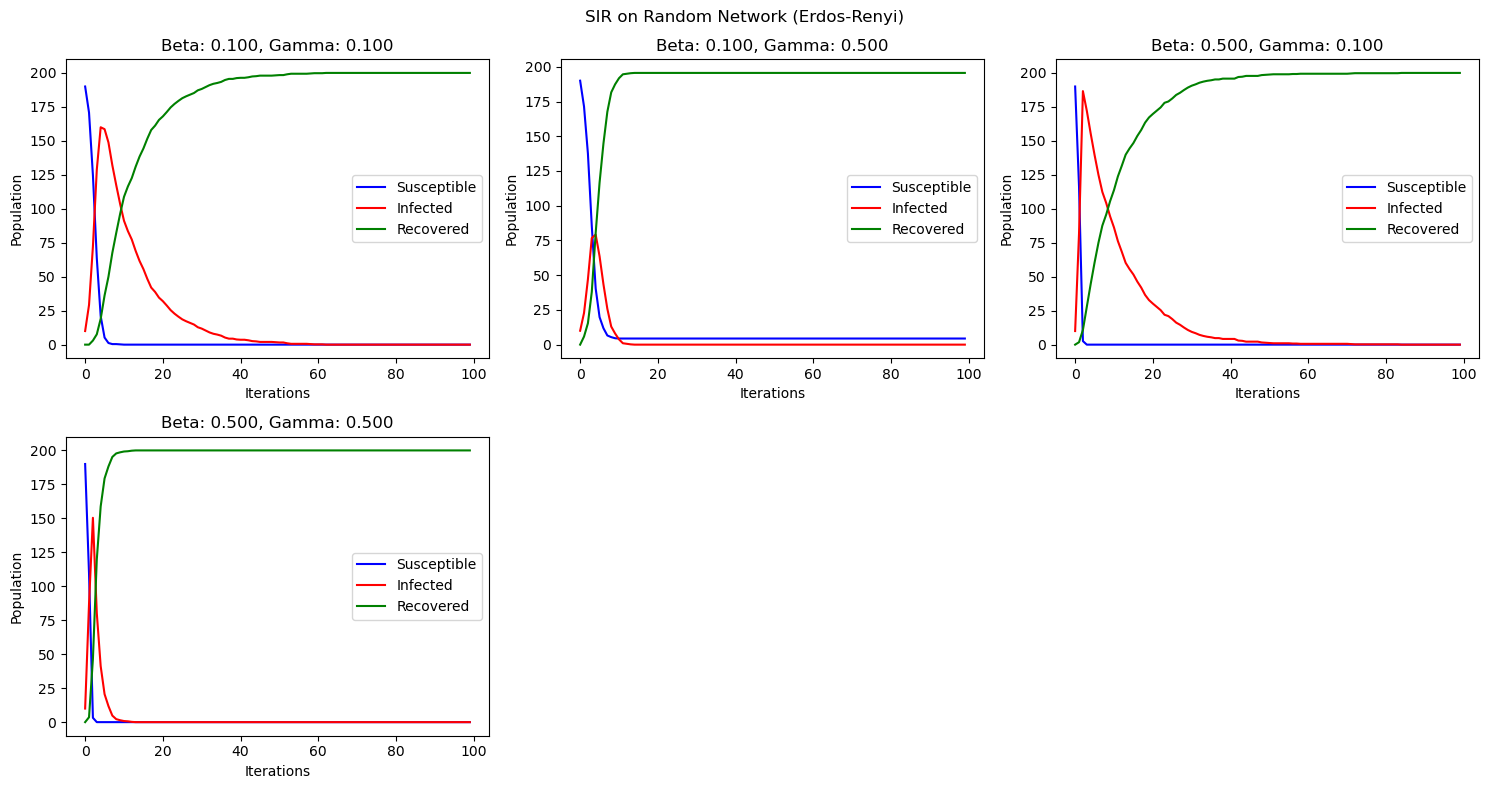

In [136]:
beta_values = np.linspace(0.1, 0.5, 2)  
gamma_values = np.linspace(0.1, 0.5, 2)  


results = experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Renyi', num_nodes=200, iterations=100)
plot_sir_results(results, "SIR on Random Network (Erdos-Renyi)")

## 2.2 Generate Networks of equivalent form

Using NetworkX generate multiple model networks with similar characteristics, again
think about the parameters associated with each network generator (e.g., Number of
nodes, connection probability,etc). Pick some network statistics (e.g., centrality measures,
degree distributions, etc.) that are interesting to measure in terms of spreading on the
network. You should generate multiple instances of each network type and then plot the
network statistics (you chose) and discuss how these statistic differ between network types
and for different parameter settings. You will use these generated networks in your SIR
experiments in the next part.

In [14]:
def get_diameter(network):
    return nx.diameter(network)

In [15]:
def get_average_path_length(network):
    return nx.average_shortest_path_length(network)

In [16]:
def get_average_degree(network):
    return 2 * network.number_of_edges() / network.number_of_nodes()

In [17]:
# Get degree historgram and display it
def show_degree_histogram(network):
    degree_histogram = nx.degree_histogram(network)

    # Histogram of the degrees
    degrees = range(len(degree_histogram))
    
    plt.bar(degrees, degree_histogram, color='lightgreen', edgecolor='black')
    
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.title('Degree Histogram')
    
    plt.show()

In [18]:
def show_degree_probability(network):
    degree_histogram = nx.degree_histogram(network)

    num_nodes = network.number_of_nodes()

    degree_probability = [frequency / num_nodes for frequency in degree_histogram]

    # Scatter plot of the probability
    plt.scatter(range(1, len(degree_histogram) + 1), degree_probability)

    plt.xlabel('Degree k')
    plt.ylabel('Probability p(k)')
    plt.title('Degree distributions')

    plt.show()

In [19]:
# Clustering Coefficient
# TODO

### Centrality measures

In [21]:
def get_average_degree_normalised(network):
    degree_centrality = nx.degree_centrality(network)
    
    return sum(c_d / num_nodes for c_d in degree_centrality.values())

In [22]:
def show_degree_centrality(network):
    degree_centrality = nx.degree_centrality(network)
    
    # Plot a histogram of degree centrality values
    plt.hist(list(degree_centrality.values()), bins=10, color='lightgreen', edgecolor='black')
    plt.title('Degree Centrality Distribution')
    plt.xlabel('Degree Centrality (normalised)')
    plt.ylabel('Frequency')
    plt.show()

In [23]:
def show_betweenness_centrality(network):
    betweenness_centrality = nx.betweenness_centrality(network)
    
    # Plot a histogram of betweenness centrality values
    plt.hist(list(betweenness_centrality.values()), bins=20, color='lightgreen', edgecolor='black')
    plt.title('Betweenness Centrality Distribution')
    plt.xlabel('Betweenness Centrality')
    plt.ylabel('Frequency')
    plt.show()

In [24]:
def show_closeness_centrality(network):
    closeness_centrality = nx.closeness_centrality(network)
    
    # Plot a histogram of closeness centrality values
    plt.hist(list(closeness_centrality.values()), bins=20, color='lightgreen', edgecolor='black')
    plt.title('Closeness Centrality Distribution')
    plt.xlabel('Closeness Centrality')
    plt.ylabel('Frequency')
    plt.show()

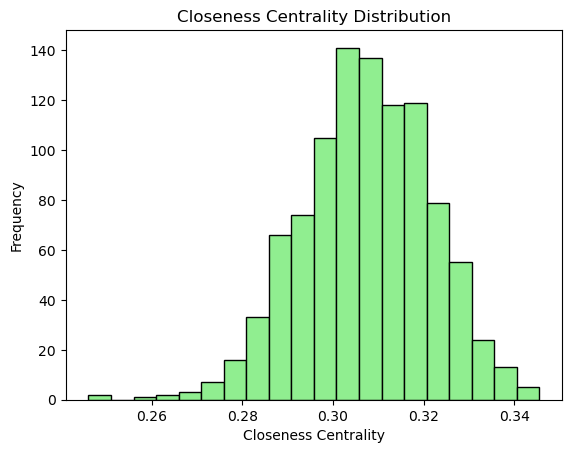

In [25]:
# Testing closeness centrality
num_nodes = 1000
p = 0.01
seed = 10
 
network = create_network('Erdos-Renyi', num_nodes, seed = seed, p = p)
show_closeness_centrality(network)

### Generate multiple networks and show statistics

In [27]:
def print_basic_network_statistics(network):
    print('Diameter =', get_diameter(network))
    print('Average path length =', get_average_path_length(network))
    print('Average degree =', get_average_degree(network))
    print('------------------------------------')

In [28]:
def generate_multiple_networks(num_networks, network_type, num_nodes, seed, p = None, m = None, k = None):
    networks = []
    
    for n in range(num_networks):
        # Generate network
        network = create_network(network_type, num_nodes, seed = seed, p = p, k = k, m = m)
        networks.append(network)

        # Update seed
        seed += 1

    return networks

In [29]:
# Generate Erdos-Renyi networks
num_networks = 5
seed = 10
num_nodes = 1000
p = 0.01
network_type = 'Erdos-Renyi'

networks = generate_multiple_networks(num_networks, network_type, num_nodes, seed, p = p)

In [30]:
# for n, network in enumerate(networks):
#     print('Statistics for network number', n + 1)
#     print_basic_network_statistics(network)

In [31]:
# Generate Barabasi-Albert networks
num_networks = 5
seed = 10
num_nodes = 1000
m = 5
network_type = 'Barabasi-Albert'

networks = generate_multiple_networks(num_networks, network_type, num_nodes, seed, m = m)

In [32]:
# for n, network in enumerate(networks):
#     print('Statistics for network number', n + 1)
#     print_basic_network_statistics(network)

In [33]:
# Generate Watts-Strogatz networks
num_networks = 5
seed = 10
num_nodes = 1000
p = 0.1
k = 10 # TODO: play with the parameters to get similar network
network_type = 'Watts-Strogatz'

networks = generate_multiple_networks(num_networks, network_type, num_nodes, seed, k = k, p = p)

In [34]:
# for n, network in enumerate(networks):
#     print('Statistics for network number', n + 1)
#     print_basic_network_statistics(network)

In [35]:
def plot_network_histograms(network):
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    
    # Plot degree histogram
    degree_histogram = nx.degree_histogram(network)
    degrees = range(len(degree_histogram))
    
    axs[0].bar(degrees, degree_histogram, color='darkolivegreen', edgecolor='black')
    axs[0].set_xlabel('Degree')
    axs[0].set_ylabel('Frequency')
    axs[0].set_title('Degree Histogram')

    # Plot degree centrality
    degree_centrality = nx.degree_centrality(network)
    
    axs[1].hist(list(degree_centrality.values()), bins=10, color='olive', edgecolor='black')
    axs[1].set_xlabel('Degree Centrality (normalised)')
    axs[1].set_ylabel('Frequency')
    axs[1].set_title('Degree Centrality Distribution')
    
    # Plot betweenness centrality
    betweenness_centrality = nx.betweenness_centrality(network)
    
    axs[2].hist(list(betweenness_centrality.values()), bins=20, color='goldenrod', edgecolor='black')
    axs[2].set_xlabel('Betweenness Centrality')
    axs[2].set_ylabel('Frequency')
    axs[2].set_title('Betweenness Centrality Distribution')
    
    # Plot closeness centrality
    closeness_centrality = nx.closeness_centrality(network)
    
    axs[3].hist(list(closeness_centrality.values()), bins=20, color='palegoldenrod', edgecolor='black')
    axs[3].set_xlabel('Closeness Centrality')
    axs[3].set_ylabel('Frequency')
    axs[3].set_title('Closeness Centrality Distribution')

    plt.tight_layout()
    plt.show()

In [36]:
# Plot histograms for each 5 networks
num_networks = 5
seed = 10
num_nodes = 1000
p = 0.01
network_type = 'Erdos-Renyi'

networks = generate_multiple_networks(num_networks, network_type, num_nodes, seed, p = p)

# TODO: align the x axis for all the networks
# for network in networks:
#     plot_network_histograms(network)

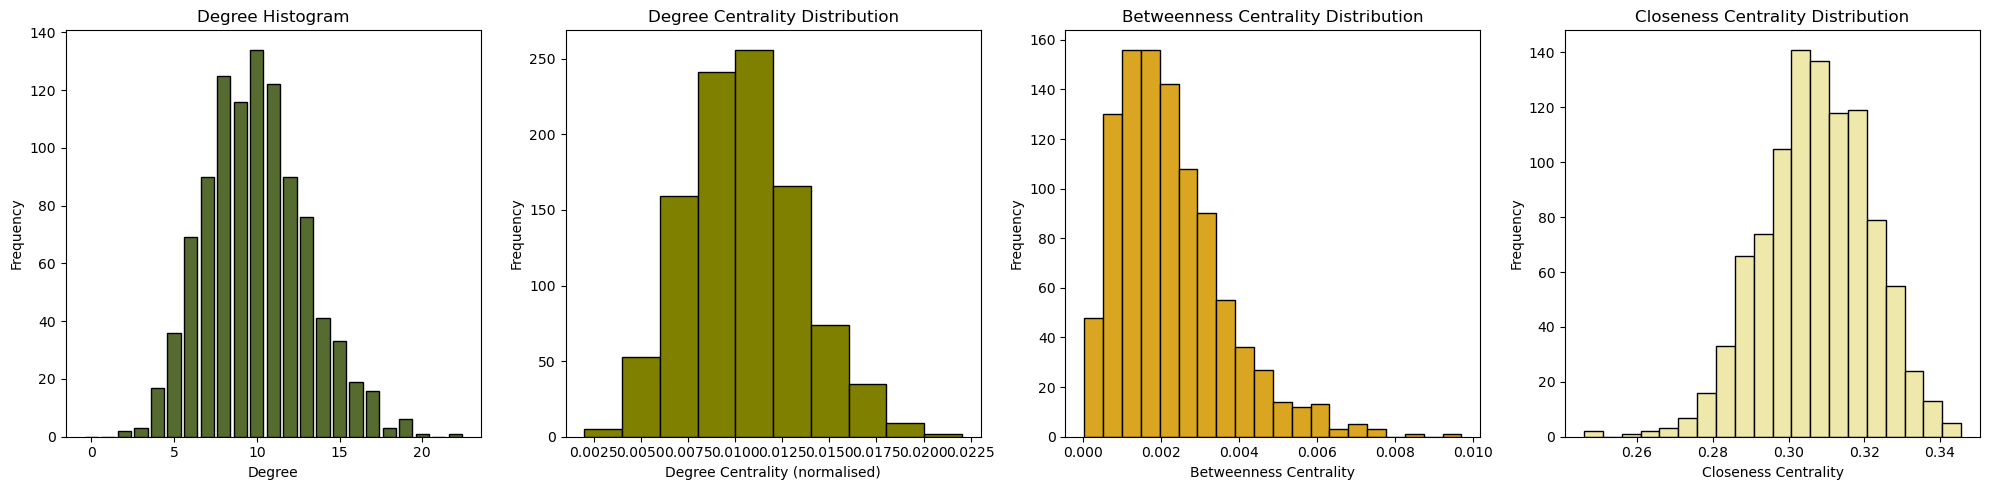

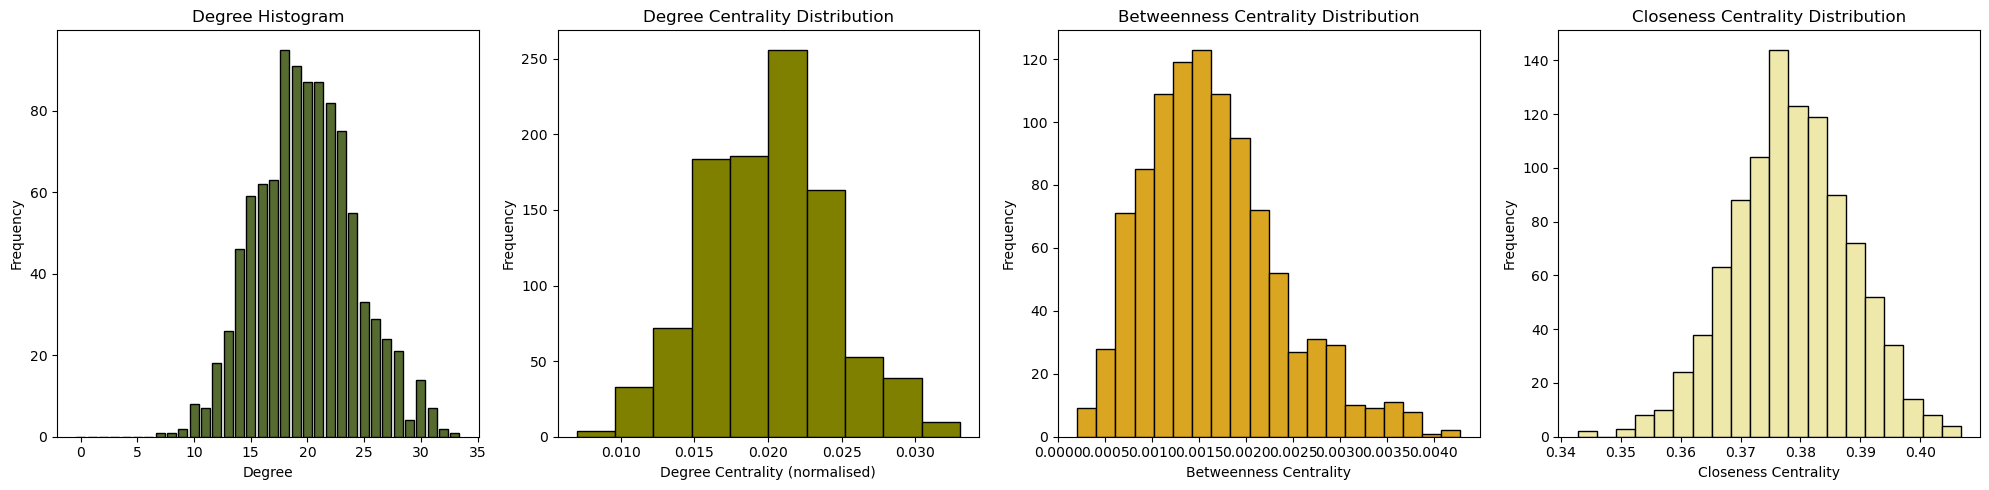

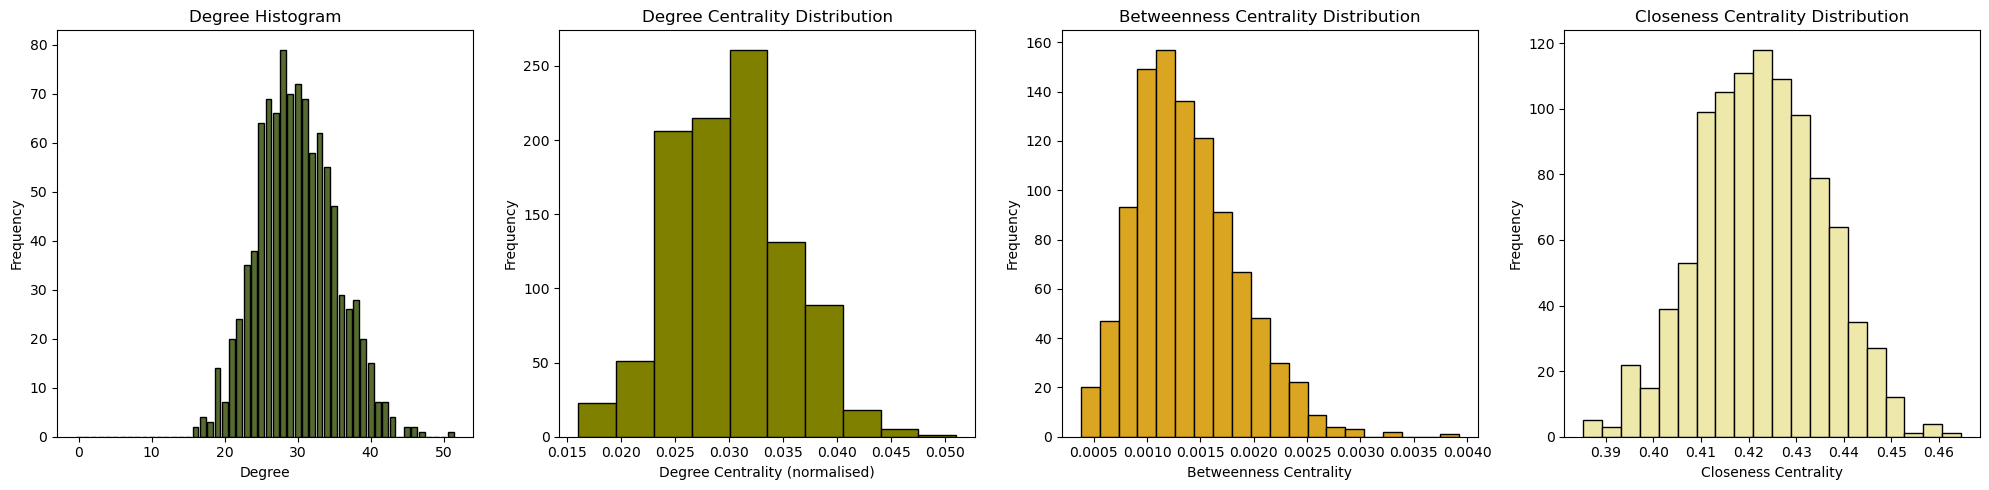

In [37]:
# Plot histograms for different p
num_networks = 5
seed = 10
num_nodes = 1000
probabilities = [0.01, 0.02, 0.03]
network_type = 'Erdos-Renyi'

networks = []
for p in probabilities:
    # Generate network
    networks.append(create_network(network_type, num_nodes, seed = seed, p = p))

# TODO: align the x axis for all the networks
for network in networks:
    plot_network_histograms(network)

## 2.3 Simulate SIR spread on the network

Simulate epidemic spreading on the networks you generated in the previous section
(NOTE: the simulations will be stochastic so think about random seeds and repitions).
You can vary the fraction of initial infected, which nodes are initially infected and other
disease parameters. Compare and discuss how the disease spreads in the different networks
under different conditions.

Running simulations on Erdos-Renyi network...


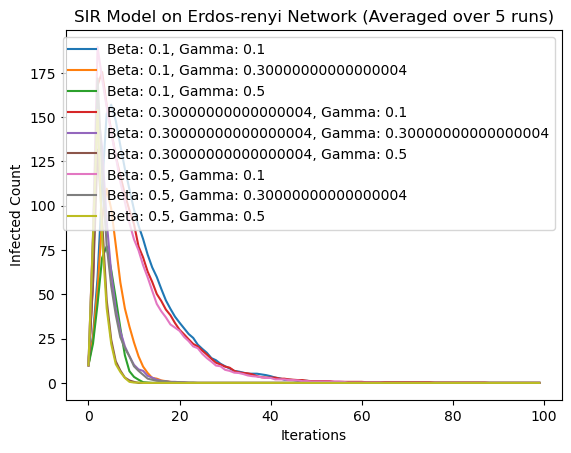

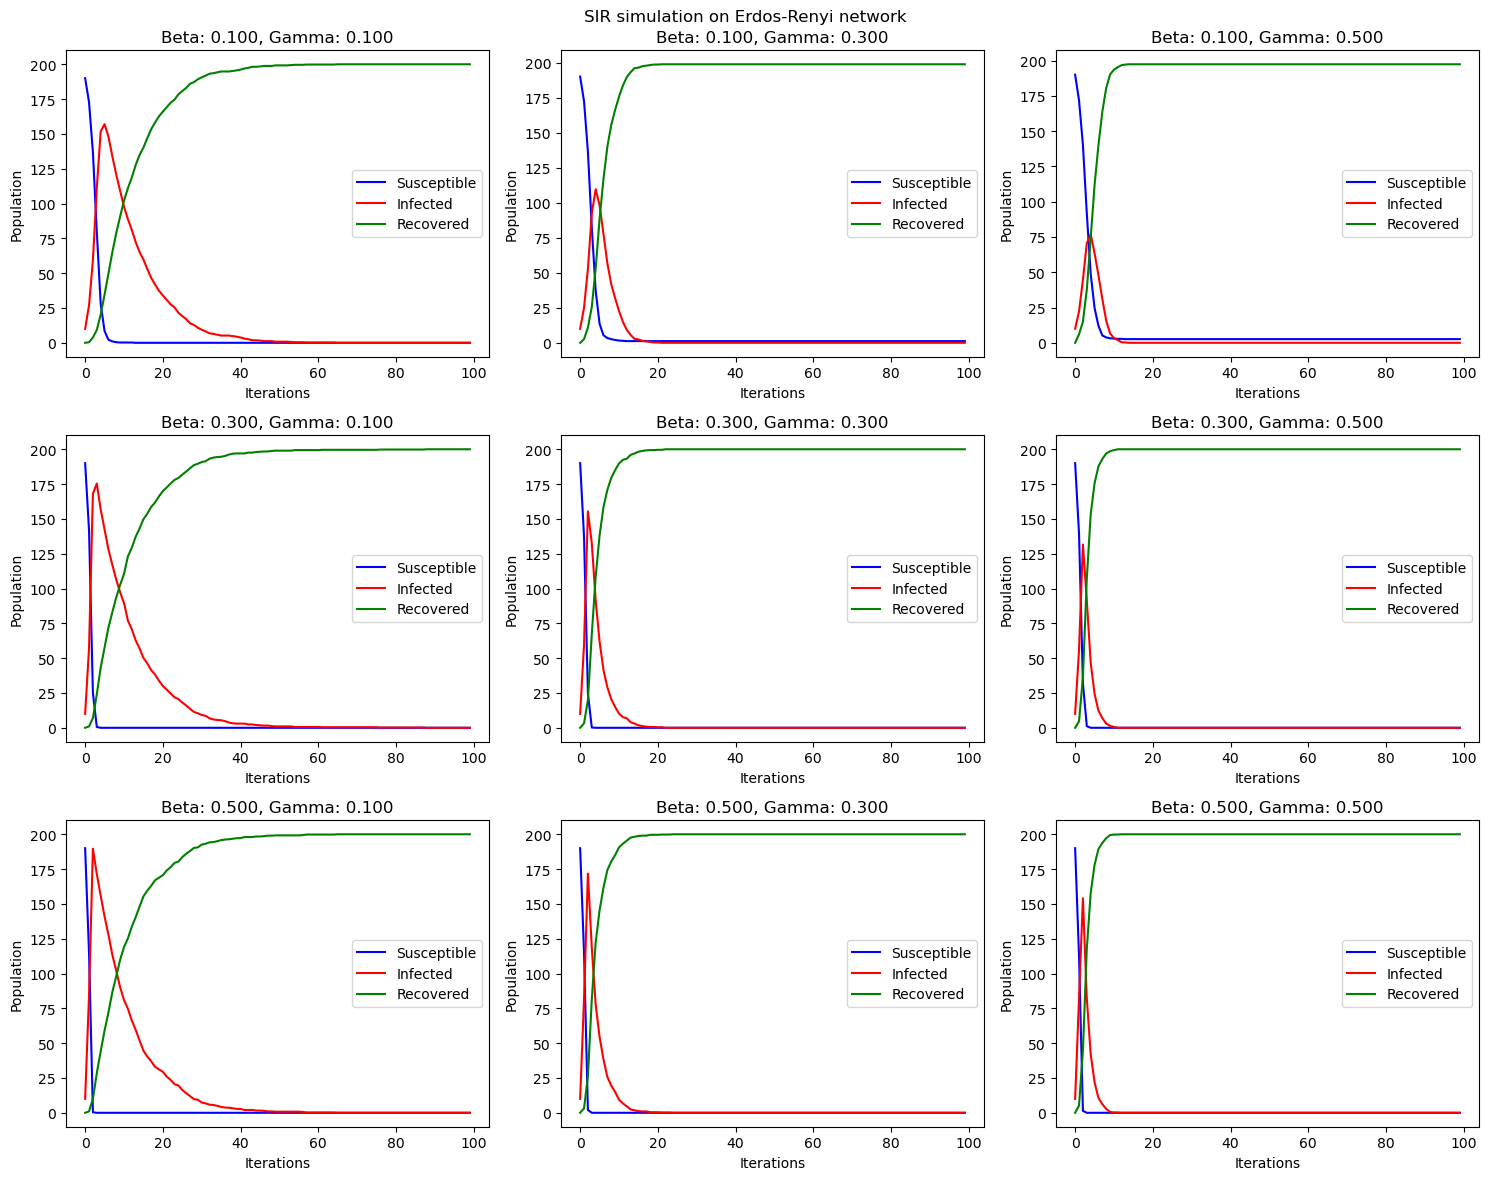

Running simulations on Barabasi-Albert network...


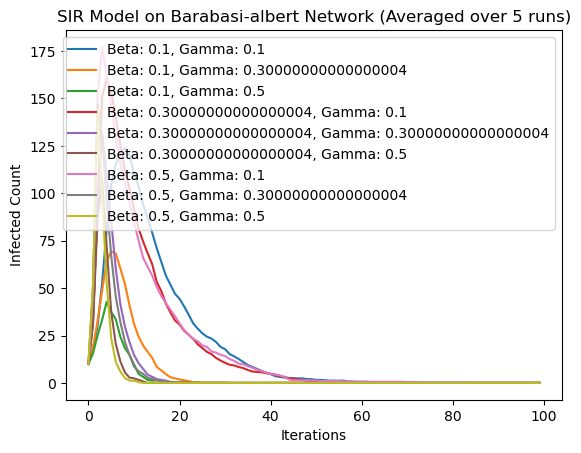

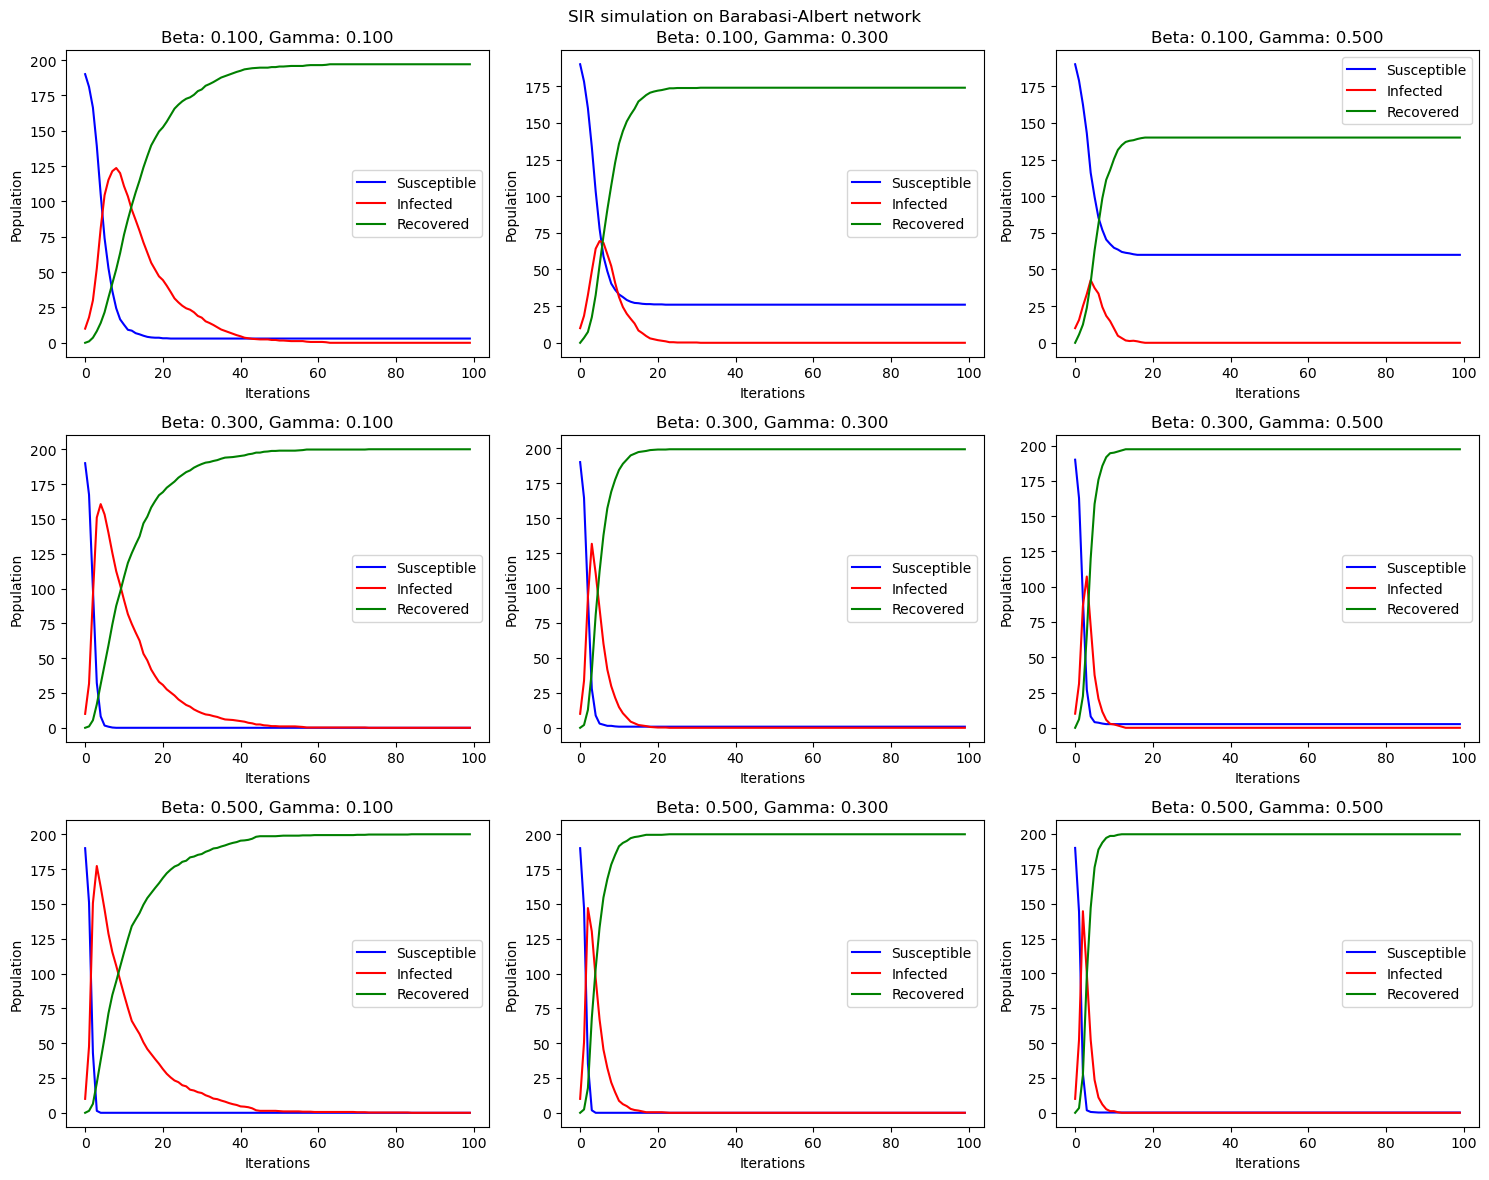

Running simulations on Watts-Strogatz network...


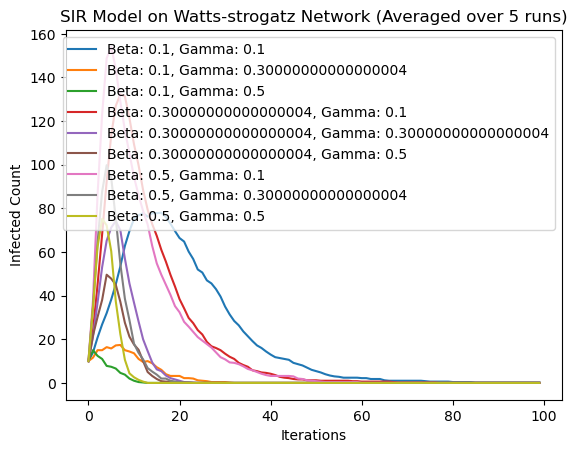

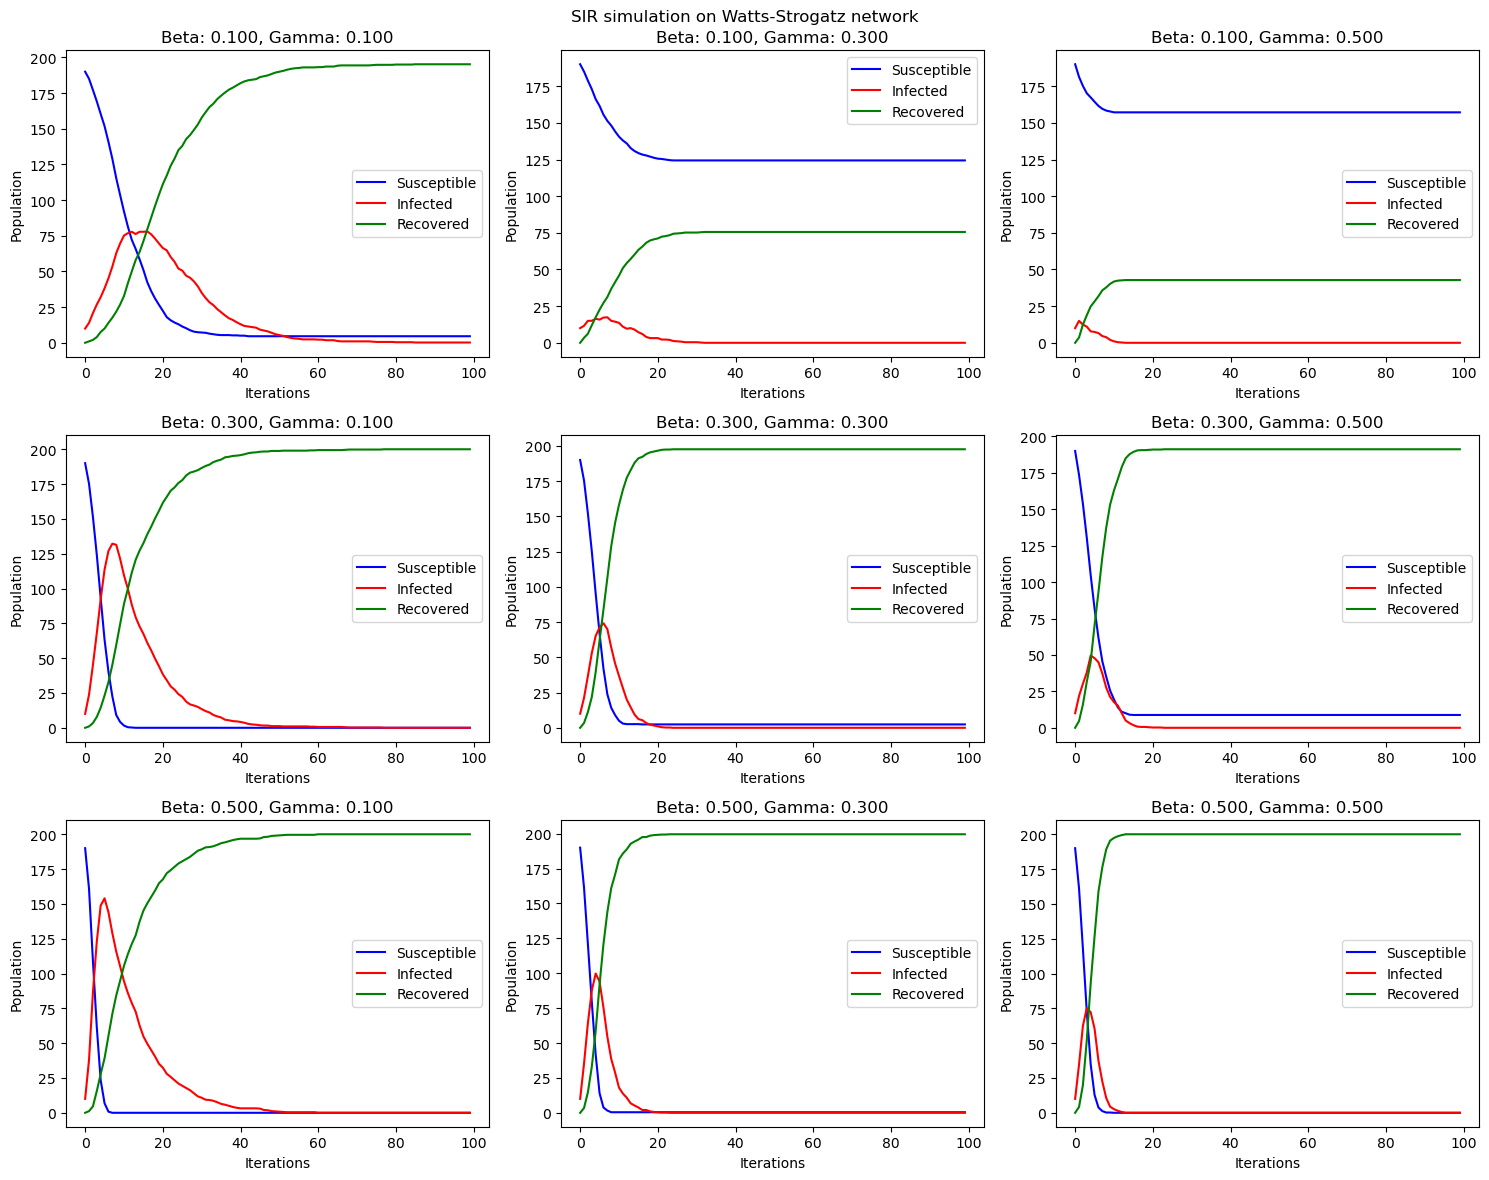

In [140]:
def experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Renyi', num_nodes=100, 
                                       initial_infected_fraction=0.01, iterations=100, repetitions=5, seed=None):
    results = {}

    # Create the network with a fixed seed for consistency
    network = create_network(network_type, num_nodes, p=0.1, seed=seed)

    # Run SIR simulations for all combinations of beta and gamma
    for beta in beta_values:
        for gamma in gamma_values:
            # Initialize accumulators for averaging across repetitions
            avg_susceptible, avg_infected, avg_recovered = None, None, None

            for rep in range(repetitions):
                susceptible, infected, recovered = run_sir_simulation(network, beta, gamma, initial_infected_fraction, iterations, seed=seed+rep)
                
                if avg_susceptible is None:
                    avg_susceptible = np.array(susceptible, dtype=float)
                    avg_infected = np.array(infected, dtype=float)
                    avg_recovered = np.array(recovered, dtype=float)
    

                else:
                    avg_susceptible += np.array(susceptible)
                    avg_infected += np.array(infected)
                    avg_recovered += np.array(recovered)

            # Average the results over repetitions
            avg_susceptible /= repetitions
            avg_infected /= repetitions
            avg_recovered /= repetitions

            # Store results
            results[(beta, gamma)] = (avg_susceptible, avg_infected, avg_recovered)

            # Plot the infected curve for each beta, gamma pair
            plt.plot(avg_infected, label=f'Beta: {beta}, Gamma: {gamma}')
    
    plt.title(f'SIR Model on {network_type.capitalize()} Network (Averaged over {repetitions} runs)')
    plt.xlabel('Iterations')
    plt.ylabel('Infected Count')
    plt.legend()
    plt.show()

    return results

# Define parameters for the experiment
beta_values = np.linspace(0.1, 0.5, 3)  # Infection probabilities to explore
gamma_values = np.linspace(0.1, 0.5, 3)  # Recovery probabilities to explore
network_types = ['Erdos-Renyi', 'Barabasi-Albert', 'Watts-Strogatz']  # Different network types
num_nodes = 200  # Number of nodes in the network
initial_infected_fraction = 0.05  # Fraction of initial infected population
iterations = 100  # Number of iterations for the SIR model
repetitions = 5  # Number of repetitions to smooth out randomness
seed = 42  # Base seed for stochasticity control

# Run experiments on each network type and plot the results
for network_type in network_types:
    print(f"Running simulations on {network_type} network...")
    results = experiment_with_varying_parameters(beta_values, gamma_values, network_type=network_type, 
                                                 num_nodes=num_nodes, initial_infected_fraction=initial_infected_fraction, 
                                                 iterations=iterations, repetitions=repetitions, seed=seed)
    plot_sir_results(results, f"SIR simulation on {network_type} network")

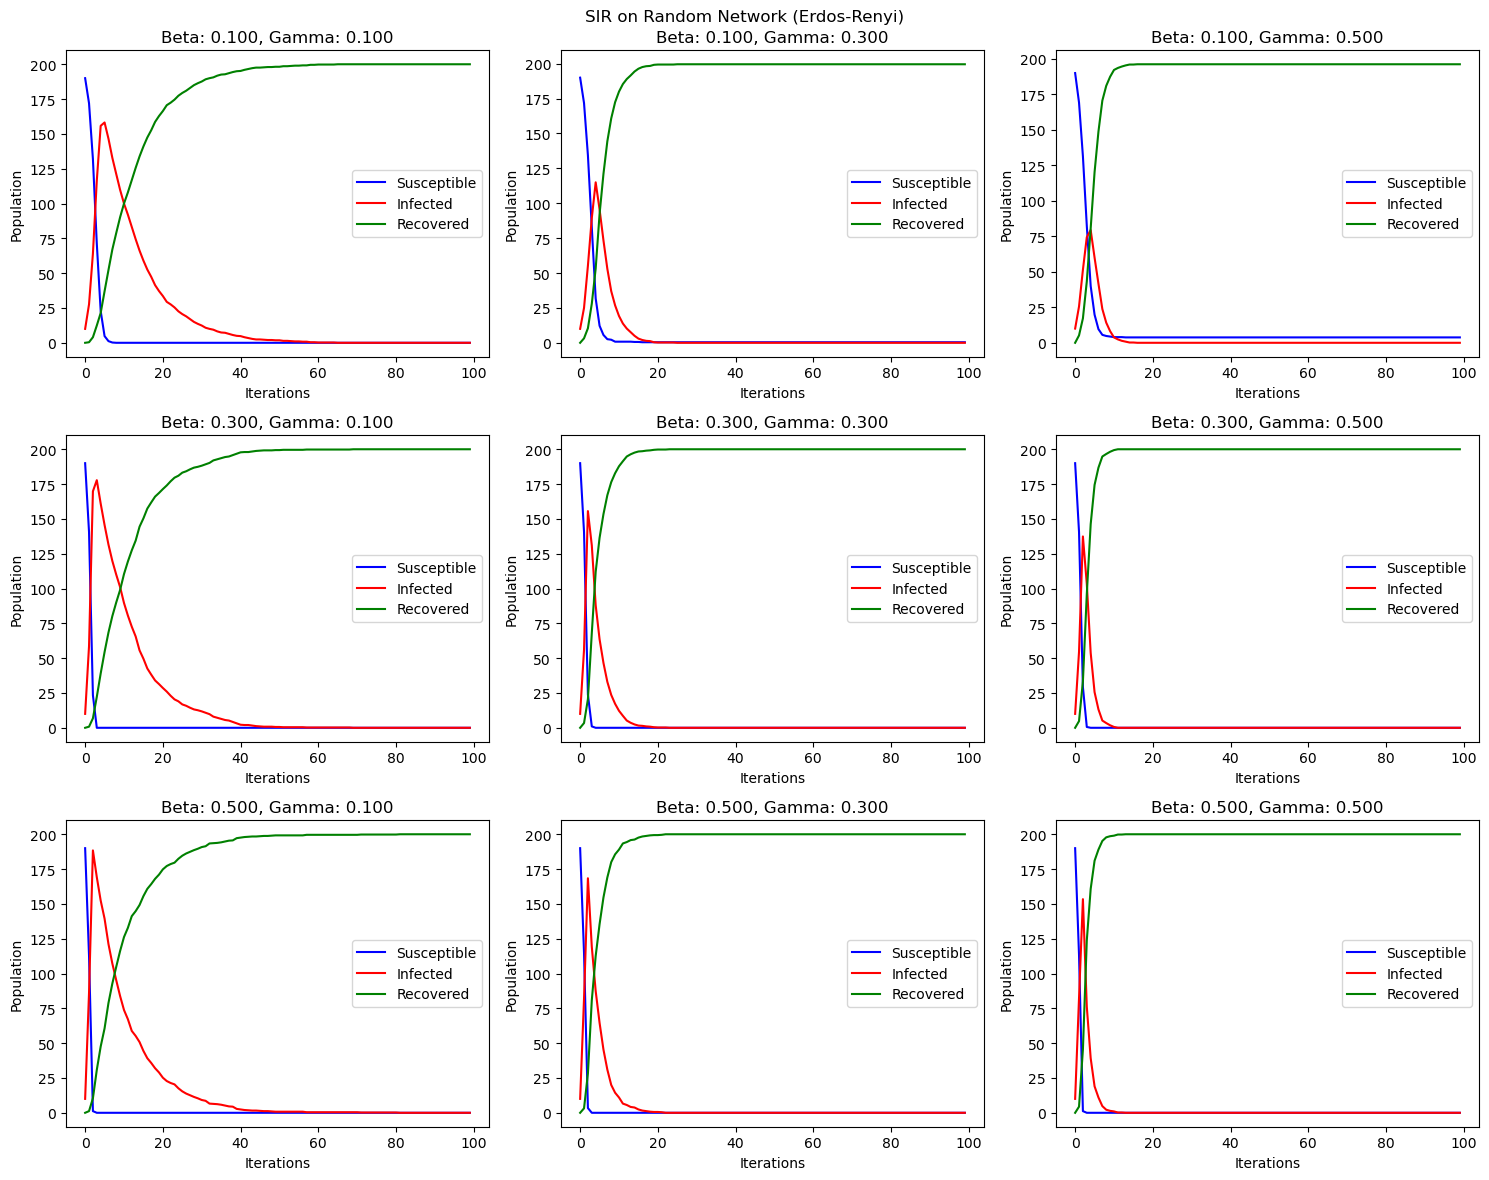

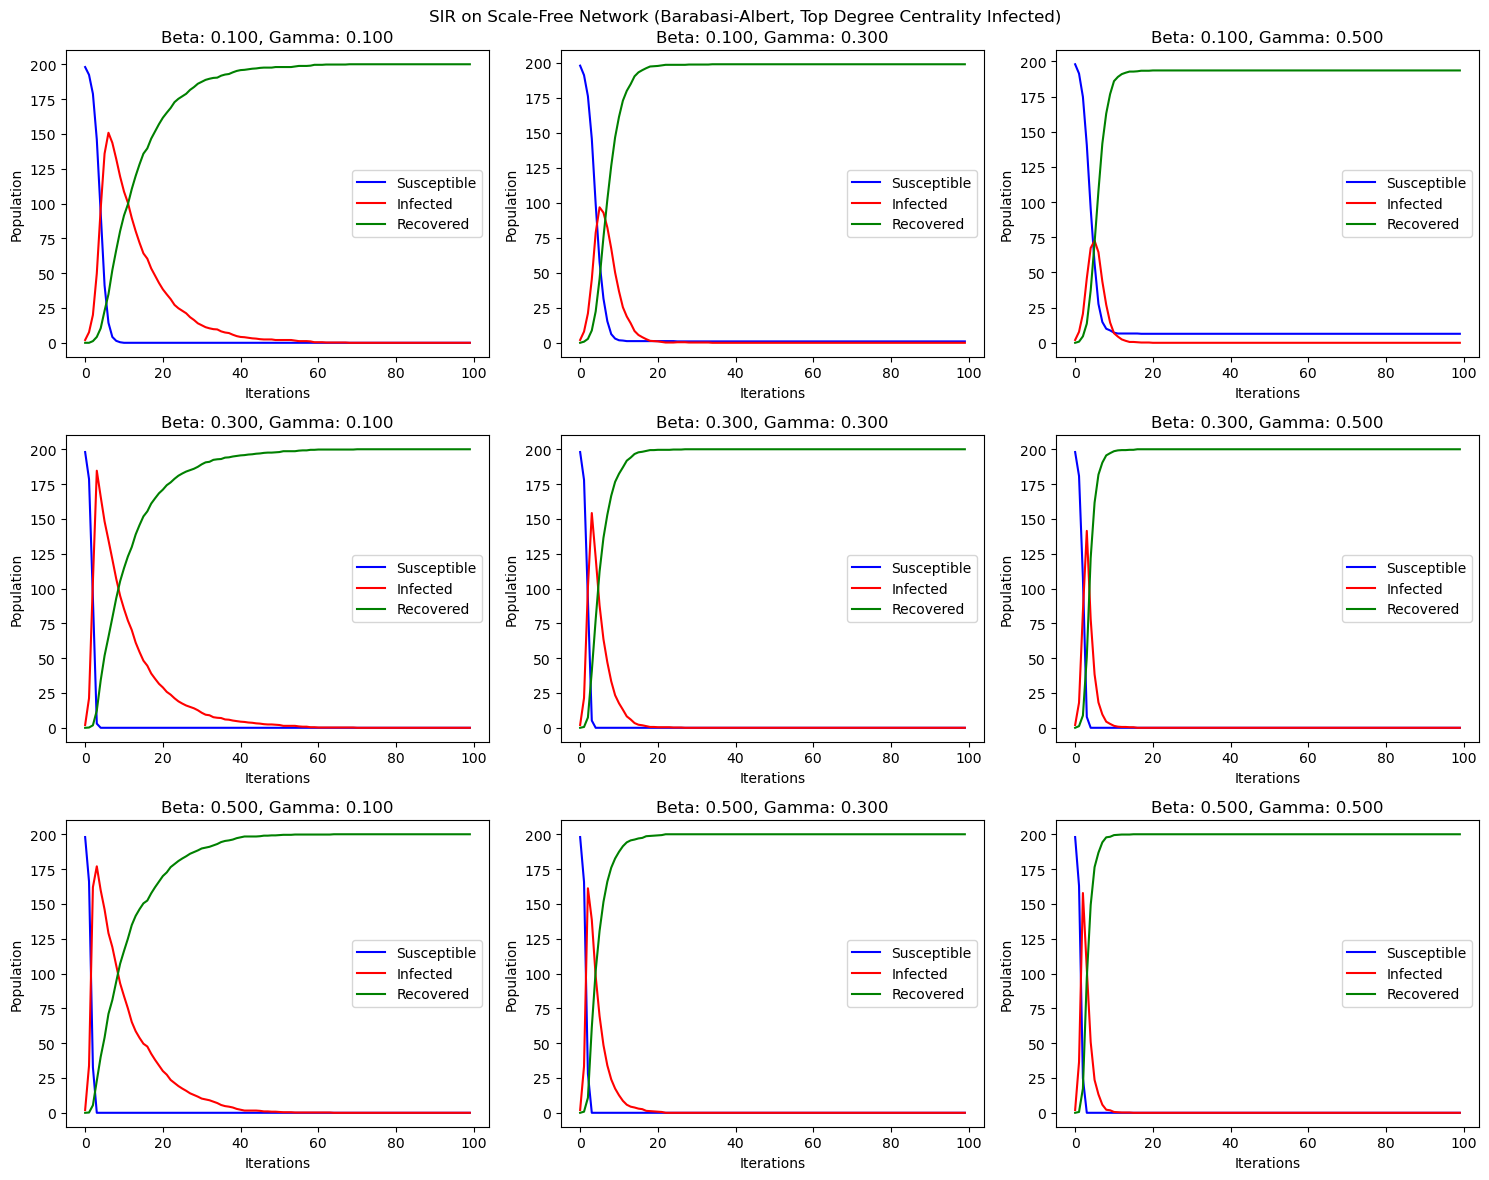

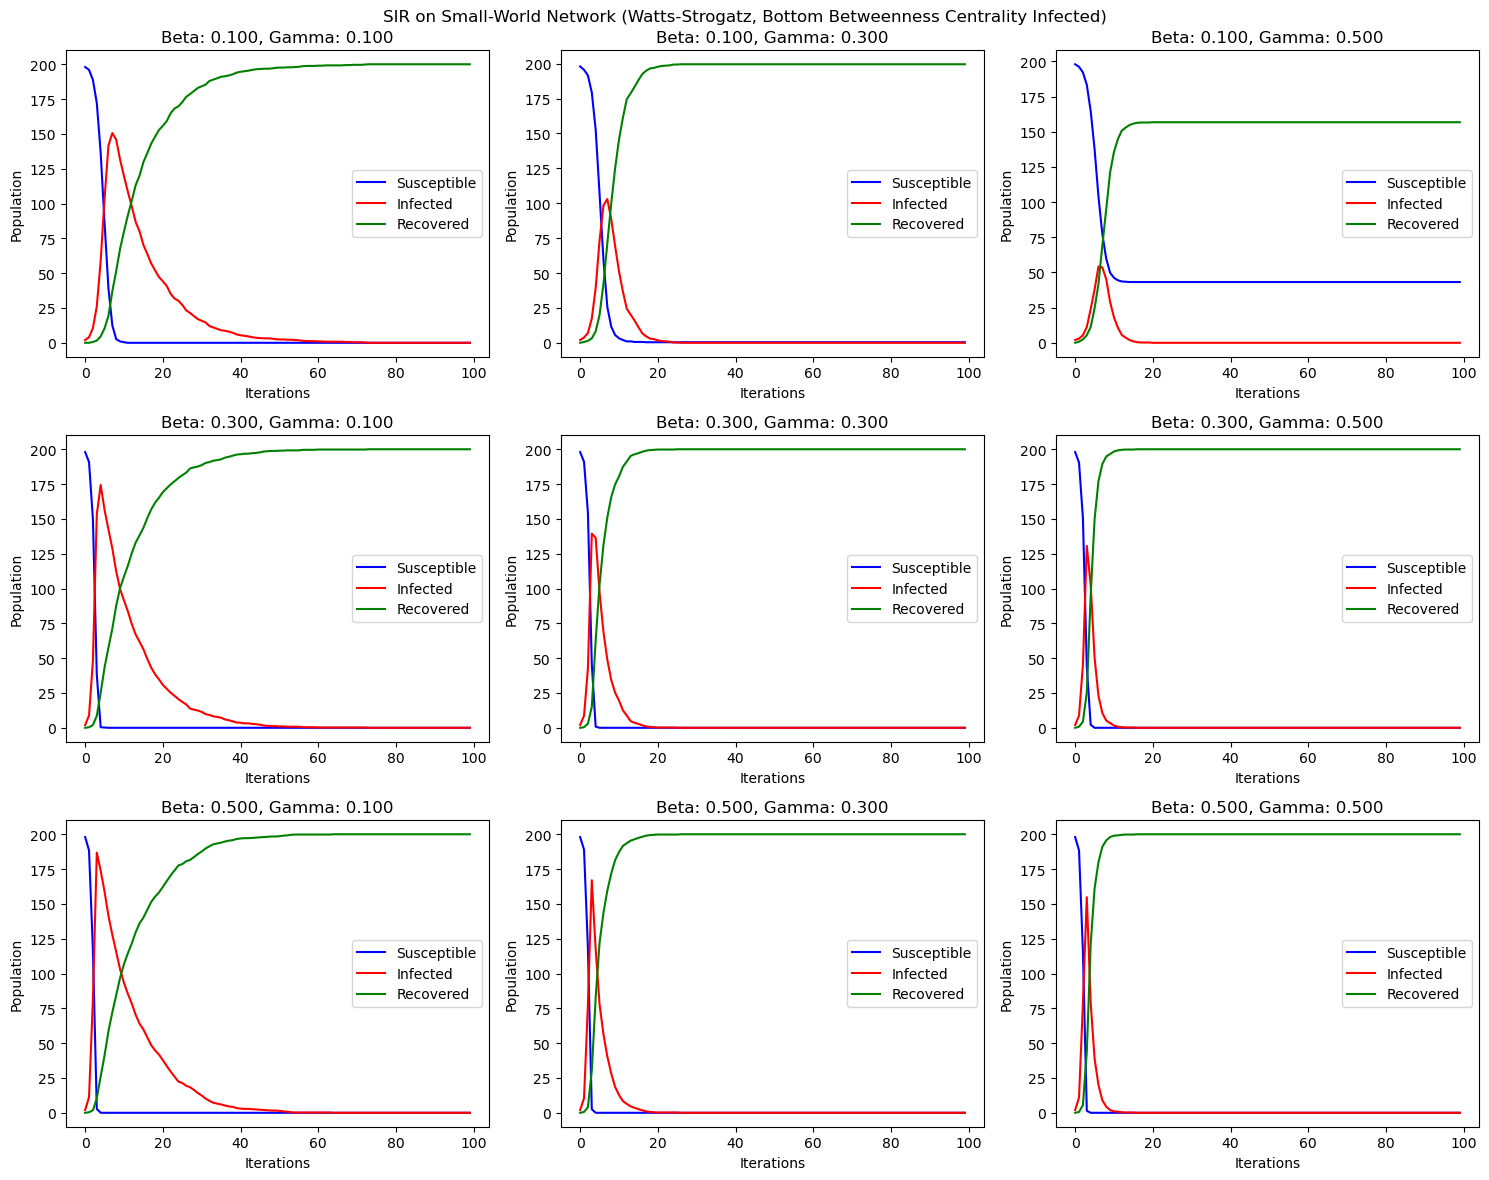

In [126]:
# Function to calculate centralities and select top/bottom nodes
def get_centrality_nodes(network, centrality_type, fraction=0.01, top=True):
    centrality = None
    if centrality_type == "degree":
        centrality = nx.degree_centrality(network)
    elif centrality_type == "betweenness":
        centrality = nx.betweenness_centrality(network)
    elif centrality_type == "closeness":
        centrality = nx.closeness_centrality(network)
    else:
        raise ValueError("Invalid centrality type. Choose from 'degree', 'betweenness', or 'closeness'.")

    sorted_nodes = sorted(centrality.items(), key=lambda item: item[1], reverse=top)
    num_infected = int(fraction * len(network.nodes))
    return [node for node, _ in sorted_nodes[:num_infected]]

# Function to run experiments with varying parameters and centrality-based infections
def experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Renyi', num_nodes=100, 
                                       initial_infected_fraction=None, initial_infected_nodes=None, 
                                       centrality_type=None, iterations=100, repetitions=5, seed=10, top=True):
    results = {}

    # Create the network
    network = create_network(network_type, num_nodes, p=0.1, seed=seed)

    # Set up initial infected nodes based on centrality if required
    if centrality_type is not None:
        initial_infected_nodes = get_centrality_nodes(network, centrality_type, fraction=initial_infected_fraction, top=top)

    # Run SIR simulations for all combinations of beta and gamma
    for beta in beta_values:
        for gamma in gamma_values:
            # Initialize accumulators for averaging across repetitions
            avg_susceptible, avg_infected, avg_recovered = None, None, None

            for rep in range(repetitions):
                susceptible, infected, recovered = run_sir_simulation(
                    network, beta, gamma, initial_infected_fraction=initial_infected_fraction if initial_infected_nodes is None else None,
                    initial_infected_nodes=initial_infected_nodes if initial_infected_nodes is not None else None, 
                    iterations=iterations
                )

                # Accumulate results
                if avg_susceptible is None:
                    avg_susceptible = np.array(susceptible, dtype=float)
                    avg_infected = np.array(infected, dtype=float)
                    avg_recovered = np.array(recovered, dtype=float)
                else:
                    avg_susceptible += np.array(susceptible)
                    avg_infected += np.array(infected)
                    avg_recovered += np.array(recovered)

            # Average the results over repetitions
            avg_susceptible /= repetitions
            avg_infected /= repetitions
            avg_recovered /= repetitions

            # Store the results
            results[(beta, gamma)] = (avg_susceptible, avg_infected, avg_recovered)

    return results

# Test and compare different network types with various infection conditions
beta_values = np.linspace(0.1, 0.5, 3)
gamma_values = np.linspace(0.1, 0.5, 3)

# 1. Vary percentage_infected
results_random = experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Renyi', 
                                                    num_nodes=200, initial_infected_fraction=0.05, iterations=100)
plot_sir_results(results_random, "SIR on Random Network (Erdos-Renyi)")

# 2. Infect nodes based on degree centrality (top 1%)
results_degree = experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Renyi', 
                                                    num_nodes=200, centrality_type='degree', initial_infected_fraction=0.01, iterations=100, top=True)
plot_sir_results(results_degree, "SIR on Scale-Free Network (Barabasi-Albert, Top Degree Centrality Infected)")

# 3. Infect nodes with least betweenness centrality (bottom 1%)
results_low_betweenness = experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Renyi', 
                                                             num_nodes=200, centrality_type='betweenness', initial_infected_fraction=0.01, iterations=100, top=False)
plot_sir_results(results_low_betweenness, "SIR on Small-World Network (Watts-Strogatz, Bottom Betweenness Centrality Infected)")


## 2.4 Dynamic Vaccination Campaign

Finally, we will conduct vaccination experiments using the sociopatterns dataset, see
Figure 1. You should design some code to load in the sociopatterns dataset (this file on
canvas includes a simple edgelist and NDLib and NetworkX provide ways to import this).

Now consider a scenario in which a disease is spreading on this network. You should run
multiple experiments, but assume that the disease always starts with a random selection
of 5 nodes infected.

You are to design a dynamic vaccination strategy in which you have a testing budget and
a limited number of vaccinations available per iteration of the model. Assume that you
have 200 tests in total, you can use a maximum number of tests per iteration (this will
vary per experiment see below), you can of course use less. You can use the tests at any
point during the spread and you may repeat tests on a node as often as you like. You
can assume that you know the network structure, but you can only discover the disease
status of a node after a test. Vaccinations can only be applied to susceptible people and
that they immediately move people to the removed state. Finally, you might consider
situations where the tests are not always accurate, but instead have some probability
(which you can vary) of being accurate. You can also assume that people remain removed
until the end of the simulation (no waning immunity).
You should compare your strategy against a simple null strategy which randomly assigns
vaccinations, you should design a strategy that at least out performs the null strategy.
Compare the strategies with different vaccination budgets of [1, 3, 5 and 10] per timestep
and compare with different testing accuracy [0.5, 0.75, 1.0] . Finally, keep in mind that
the purpose of the assignment is not to design the best strategy, but to evaluate you
strategy in a systematic and scientific manner.

### Load edgelist and generate a network from it

In [45]:
def generate_conference_network():
    # Load the CSV data into a matrix
    nodes_and_edges_matrix = np.genfromtxt('transmission_network.csv', delimiter = ';')
    
    # Get the nodes and edges
    nodes = nodes_and_edges_matrix[1:,0]
    edges_matrix = nodes_and_edges_matrix[1:,1:]
    
    num_nodes = len(nodes)
    nodes = [str(node) for node in nodes]
    
    # Initialize the network with all the nodes
    network = nx.Graph()
    network.add_nodes_from(nodes)
    
    # Add the edges to the network
    for row in range(num_nodes):
        for col in range(row + 1, num_nodes):
            if edges_matrix[row, col] != 0:
                network.add_edge(nodes[row], nodes[col])
                
    return network

### Run SIR simulation without vaccination

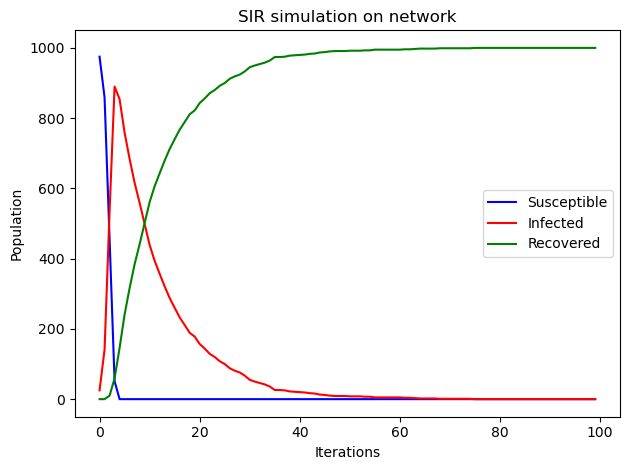

In [47]:
# Set parameters
beta = 1/7
gamma = 1/10
initial_infected_fraction = 5/num_nodes # we have 5 random infected nodes at the beginning

susceptible, infected, recovered = run_sir_simulation(network, beta, gamma, initial_infected_fraction, iterations=100)

# Plot
plt.plot(susceptible, label='Susceptible', color='blue')
plt.plot(infected, label='Infected', color='red')
plt.plot(recovered, label='Recovered', color='green')

plt.title('SIR simulation on network') # TODO: improve
plt.xlabel('Iterations') # TODO: improve
plt.ylabel('Population') # TODO: improve
plt.legend()
plt.tight_layout()
plt.show()

### Null strategy

In [50]:
def simulate_null_vaccination_strategy(network, beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations = 100):
    model = generate_model(network, beta, gamma, initial_infected_nodes)

    # Initially, no node was vaccinated yet
    not_vaccinated_nodes = list(network.nodes())

    # Initialize variables
    susceptibles = [369] # 374 - 5 who were initially infected
    infecteds = [5]
    recovered = [0]
    extinction = False
    vaccinations_used = 0

    for iteration in range(max_iterations):
        # Run an iteration
        result = model.iteration()
    
        # Check that there are still some infecteds left
        if result['node_count'][1] < 1:
            extinction = True
            break

        # Add the result to the respective lists
        susceptibles.append(result['node_count'][0])
        infecteds.append(result['node_count'][1])
        recovered.append(result['node_count'][2])
    
        # Get the current status of the nodes
        status = model.status
    
        # Pick nodes that are supposed to be vaccinated randomly
        if len(not_vaccinated_nodes) < vaccination_budget:
            nodes_to_vaccinate = not_vaccinated_nodes
        else:
            nodes_to_vaccinate = np.random.choice(not_vaccinated_nodes, vaccination_budget, replace = False)
        
        # Vaccinate by changing the status (vaccination only works when not infected, so the only chage is from S -> R)
        for node in nodes_to_vaccinate:
            # Remove node from the list of not vaccinated nodes
            not_vaccinated_nodes.remove(node)
            # We vaccinate every node maximum once. Even if we do not test, either the node was sucsceptible and it goes to R, or it was alredy in R or in I and once it recovers it will go to R.
            if status[node] == 0:
                model.status[node] = 2

        vaccinations_used += len(nodes_to_vaccinate)
    
    return {'susceptibles': susceptibles, 'infecteds': infecteds, 'recovered': recovered, 'extinction': extinction, 'vaccinations_used': vaccinations_used, 'number_of_iterations': iteration + 1}

In [51]:
# Test one run of the null strategy
# Generate network and set parameters
network = generate_conference_network()
beta = 1/5
gamma = 1/10
vaccination_budget = 5
initial_infected_nodes = np.random.choice(list(network.nodes()), vaccination_budget, replace=False)
max_iterations = 100

simulation_result = simulate_null_vaccination_strategy(network, beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations)

In [52]:
print(simulation_result)

{'susceptibles': [369, 369, 357, 339, 315, 264, 197, 132, 93, 70, 56, 51, 46, 42, 38, 34, 32, 31, 31, 31, 29, 29, 28, 26, 26, 26, 25, 24, 24, 24, 24, 24, 24, 23, 22, 22, 22, 22, 21, 21, 21, 21, 21, 21, 21, 20, 19, 19, 19, 17, 17, 16, 16, 15, 14, 12, 11, 10, 10, 10, 9], 'infecteds': [5, 5, 12, 23, 41, 85, 140, 183, 192, 197, 185, 167, 158, 151, 141, 137, 129, 114, 104, 95, 85, 76, 66, 56, 47, 44, 41, 39, 36, 35, 32, 27, 25, 23, 21, 20, 20, 18, 17, 17, 16, 15, 13, 10, 9, 8, 8, 7, 7, 5, 5, 4, 4, 4, 3, 2, 2, 1, 1, 1, 1], 'recovered': [0, 0, 5, 12, 18, 25, 37, 59, 89, 107, 133, 156, 170, 181, 195, 203, 213, 229, 239, 248, 260, 269, 280, 292, 301, 304, 308, 311, 314, 315, 318, 323, 325, 328, 331, 332, 332, 334, 336, 336, 337, 338, 340, 343, 344, 346, 347, 348, 348, 352, 352, 354, 354, 355, 357, 360, 361, 363, 363, 363, 364], 'extinction': True, 'vaccinations_used': 300, 'number_of_iterations': 61}


In [53]:
# Run 50 simulations of the null vaccination strategy for the same 5 initially infected nodes
# Generate network and set parameters
network = generate_conference_network()
beta = 1/7
gamma = 1/10
vaccination_budget = 5
initial_infected_nodes = np.random.choice(list(network.nodes()), vaccination_budget, replace=False)
max_iterations = 100

results = []

for simulation in range(50):
    results.append(simulate_null_vaccination_strategy(network, beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations))

In [54]:
# Investigate the results
peak_number_of_infecteds = []
vaccinations_used = []
number_of_iterations = []

for result in results:
    peak_number_of_infecteds.append(max(result['infecteds']))
    vaccinations_used.append(result['vaccinations_used'])
    number_of_iterations.append(result['number_of_iterations'])

print('Average peak of number of infecteds:', np.average(peak_number_of_infecteds))
print('Average number of vaccinations used:', np.average(vaccinations_used))
print('Average number of iterations until extinction:', np.average(number_of_iterations))

Average peak of number of infecteds: 176.6
Average number of vaccinations used: 330.82
Average number of iterations until extinction: 70.08


### Our vaccination strategy -- centrality

In [56]:
def simulate_centrality_vaccination_strategy(network, centrality_type, beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations = 100):
    # Generate model
    model = generate_model(network, beta, gamma, initial_infected_nodes)

    # Initialize variables
    susceptibles = [369] # 374 - 5 who were initially infected
    infecteds = [5]
    recovered = [0]
    extinction = False
    vaccinations_used = 0
    tests_used = 0

    # Get the centrality for all nodes and sort it
    if centrality_type == 'degree':
        centrality = nx.degree_centrality(network)
    elif centrality_type == 'betweenness':
        centrality = nx.betweenness_centrality(network)
    elif centrality_type == 'closeness':
        centrality = nx.closeness_centrality(network)
    else:
        raise ValueError('Invalid centrality type. Choose from "degree", "betweenness", or "closeness".')

    sorted_nodes = sorted(centrality.items(), key = lambda item: item[1])

    for iteration in range(max_iterations):
        # Get the current status of all nodes
        status = model.status

        # Test the nodes with highest degree centrality and vaccinate until you use all the vaccinations
        vaccinations_used_current_iter = 0
        while vaccinations_used_current_iter < vaccination_budget:
            # Check if there are any possible nodes left and get the node with highest degree centrality
            # TODO: clean up a bit
            if len(sorted_nodes) == 0:
                return {'susceptibles': susceptibles, 'infecteds': infecteds, 'recovered': recovered, 'extinction': extinction, 'vaccinations_used': vaccinations_used, 'number_of_iterations': iteration, 'tests_used': tests_used}

            node = sorted_nodes.pop()
            
            # If we still have tests left, test first and then vaccinate, if not, vaccinate anyway
            if tests_used < 200:
                # Check if the node is susceptible and if yes, vaccinate it, but do not vaccinate otherwise
                if status[node[0]] == 0:
                    model.status[node[0]] = 2
                    vaccinations_used_current_iter += 1
                tests_used += 1
            else:
                # Vaccinate, no matter the status (but effectivelly, the status will only change if susceptible)
                if status[node[0]] == 0:
                    model.status[node[0]] = 2
                vaccinations_used_current_iter += 1
    
        vaccinations_used += vaccinations_used_current_iter
            
        # Run an iteration
        result = model.iteration()
    
        # Check that there are still some infecteds left
        if result['node_count'][1] < 1:
            extinction = True
            break
    
        # Add the result to the respective lists
        susceptibles.append(result['node_count'][0])
        infecteds.append(result['node_count'][1])
        recovered.append(result['node_count'][2])

    return {'susceptibles': susceptibles, 'infecteds': infecteds, 'recovered': recovered, 'extinction': extinction, 'vaccinations_used': vaccinations_used, 'number_of_iterations': iteration + 1, 'tests_used': tests_used}

In [121]:
# TEST multiple simulations TODO remove
network = generate_conference_network()
centrality_type = 'betweenness'
beta = 1/7
gamma = 1/10
vaccination_budget = 5
initial_infected_nodes = np.random.choice(list(network.nodes()), vaccination_budget, replace=False)
max_iterations = 100

results = []

for simulation in range(50):
    results.append(simulate_centrality_vaccination_strategy(network, centrality_type, beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations))

In [122]:
# Investigate the results TODO remove
get_result_stats(results)

Average peak of number of infecteds: 94.24
Average number of vaccinations used: 266.5
Average number of iterations until extinction: 53.3


### Compare multiple strategies

In [60]:
def get_all_strategies_results(network, beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations, number_of_simulations):
    null_strategy_results = []
    degree_centrality_strategy_results = []
    betweenness_centrality_strategy_results = []
    closenesss_centrality_strategy_results = []

    for simulation in range(number_of_simulations):
        null_strategy_results.append(simulate_null_vaccination_strategy(network, beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations))
        degree_centrality_strategy_results.append(simulate_centrality_vaccination_strategy(network, 'degree', beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations))
        betweenness_centrality_strategy_results.append(simulate_centrality_vaccination_strategy(network, 'betweenness', beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations))
        closenesss_centrality_strategy_results.append(simulate_centrality_vaccination_strategy(network, 'closeness', beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations))

    return [null_strategy_results, degree_centrality_strategy_results, betweenness_centrality_strategy_results, closenesss_centrality_strategy_results]

In [61]:
def get_result_stats(results):
    peak_number_of_infecteds = []
    vaccinations_used = []
    number_of_iterations = []
    
    for result in results:
        peak_number_of_infecteds.append(max(result['infecteds']))
        vaccinations_used.append(result['vaccinations_used'])
        number_of_iterations.append(result['number_of_iterations'])
    
    print('Average peak of number of infecteds:', np.average(peak_number_of_infecteds))
    print('Average number of vaccinations used:', np.average(vaccinations_used))
    print('Average number of iterations until extinction:', np.average(number_of_iterations))

In [62]:
network = generate_conference_network()
beta = 1/7
gamma = 1/10
vaccination_budget = 5
initial_infected_nodes = np.random.choice(list(network.nodes()), vaccination_budget, replace=False)
max_iterations = 100
number_of_simulations = 50

# TODO run for different initial infected nodes

results = get_all_strategies_results(network, beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations, number_of_simulations)

In [63]:
print('Null strategy results')
get_result_stats(results[0])
print('Degree centrality strategy results')
get_result_stats(results[1])
print('Betweenness centrality strategy results')
get_result_stats(results[2])
print('Closenesss centrality strategy results')
get_result_stats(results[3])

Null strategy results
Average peak of number of infecteds: 174.32
Average number of vaccinations used: 320.68
Average number of iterations until extinction: 65.98
Degree centrality strategy results
Average peak of number of infecteds: 68.9
Average number of vaccinations used: 279.7
Average number of iterations until extinction: 55.94
Betweenness centrality strategy results
Average peak of number of infecteds: 75.12
Average number of vaccinations used: 276.0
Average number of iterations until extinction: 55.2
Closenesss centrality strategy results
Average peak of number of infecteds: 92.38
Average number of vaccinations used: 278.6
Average number of iterations until extinction: 55.72
